# Test 07 — Persistent Memory: Titans vs No Memory

## Goal

Check whether **TitansMemory** lets the BeliefField maintain a representation of an object during occlusion (object hidden for N frames, then revealed).

## Hypothesis

- **With Titans**: the model keeps a trace of the object in persistent memory, enabling quality reconstruction even after occlusion.
- **Without Titans**: reconstruction quality degrades fast because the PDE alone "forgets" (information diffuses away).

## Metrics

- **MSE** after occlusion: reconstruction error
- **SSIM**: structural similarity (more sensitive to structure than intensity)
- **Decay curve**: quality vs occlusion duration
- **Surprise gate activation**: when does the system get "surprised"?

## Why this matters

A world model must predict the state of the world even when things are hidden. This is **object permanence** (Piaget). Titans acts as a long-term memory that persists beyond the local PDE dynamics.

In [1]:
import sys
import os

FLUIDWORLD_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if FLUIDWORLD_ROOT not in sys.path:
    sys.path.insert(0, FLUIDWORLD_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from fluidworld.core.belief_field import BeliefField, TitansMemory, DeltaNetTemporal
from fluidworld.core.diffusion import Laplacian2D
from fluidworld.core.fluid_layer import RMSNorm

print(f"FluidWorld root: {FLUIDWORLD_ROOT}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

FluidWorld root: c:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld
PyTorch: 2.10.0+cu128
Device: cuda


## 1. Configuration

In [2]:
CHANNELS = 64
SPATIAL_HW = 16
BATCH_SIZE = 4
STIMULUS_DIM = 6

N_SHOW_FRAMES = 10    # Nombre de frames ou l'objet est visible
MAX_OCCLUSION = 30    # Duree maximale d'occlusion a tester
N_RECOVERY_FRAMES = 5 # Frames apres re-exposition

print(f"Configuration : {CHANNELS} canaux, {SPATIAL_HW}x{SPATIAL_HW}")
print(f"Protocole : {N_SHOW_FRAMES} frames visibles, occlusion 1-{MAX_OCCLUSION}, {N_RECOVERY_FRAMES} frames recovery")

Configuration : 64 canaux, 16x16
Protocole : 10 frames visibles, occlusion 1-30, 5 frames recovery


## 2. Synthetic object

We create an "object" as a fixed spatial pattern in feature space. During occlusion, we send zeros (no observation).

Forme de l'objet : torch.Size([4, 64, 16, 16])
Energie de l'objet : 1615.80


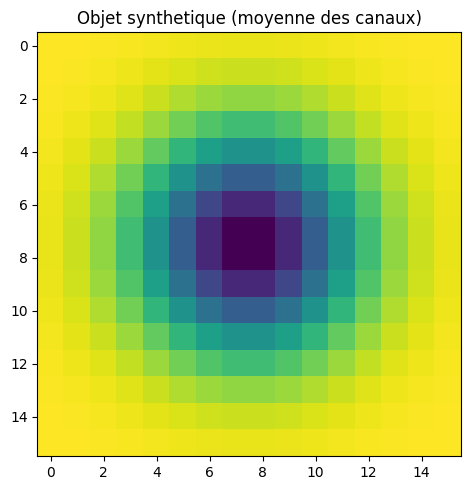

In [3]:
def create_synthetic_object(batch_size, channels, spatial_hw, device, seed=42):
    """
    Cree un objet synthetique : un pattern spatial fixe.
    Simule un encodage de type "objet dans la scene".
    """
    torch.manual_seed(seed)
    # Un pattern spatial structure (cercle gaussien + texture)
    y_coords = torch.linspace(-1, 1, spatial_hw, device=device)
    x_coords = torch.linspace(-1, 1, spatial_hw, device=device)
    yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')
    
    # Gaussienne 2D centree (l'objet)
    gaussian = torch.exp(-(xx**2 + yy**2) / 0.3)
    
    # Projeter sur les canaux avec des poids aleatoires
    weights = torch.randn(channels, device=device)
    obj = gaussian.unsqueeze(0) * weights.unsqueeze(-1).unsqueeze(-1)  # (C, H, W)
    obj = obj.unsqueeze(0).expand(batch_size, -1, -1, -1)  # (B, C, H, W)
    
    return obj

# Visualiser l'objet
obj = create_synthetic_object(BATCH_SIZE, CHANNELS, SPATIAL_HW, device)
print(f"Forme de l'objet : {obj.shape}")
print(f"Energie de l'objet : {(obj**2).sum(dim=(1,2,3)).mean().item():.2f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(obj[0].mean(dim=0).cpu().numpy(), cmap='viridis')
ax.set_title('Objet synthetique (moyenne des canaux)')
plt.tight_layout()
plt.show()

## 3. SSIM function

Simplified SSIM for latent fields.

In [4]:
def compute_ssim_field(field_a, field_b):
    """
    SSIM simplifie pour champs latents (B, C, H, W).
    Retourne un scalaire moyen.
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    
    # Moyenner sur canaux -> (B, 1, H, W)
    a = field_a.mean(dim=1, keepdim=True)
    b = field_b.mean(dim=1, keepdim=True)
    
    mu_a = F.avg_pool2d(a, kernel_size=3, stride=1, padding=1)
    mu_b = F.avg_pool2d(b, kernel_size=3, stride=1, padding=1)
    
    sigma_a_sq = F.avg_pool2d(a ** 2, 3, 1, 1) - mu_a ** 2
    sigma_b_sq = F.avg_pool2d(b ** 2, 3, 1, 1) - mu_b ** 2
    sigma_ab = F.avg_pool2d(a * b, 3, 1, 1) - mu_a * mu_b
    
    ssim = ((2 * mu_a * mu_b + C1) * (2 * sigma_ab + C2)) / \
           ((mu_a ** 2 + mu_b ** 2 + C1) * (sigma_a_sq + sigma_b_sq + C2))
    
    return ssim.mean().item()

## 4. Occlusion protocol

1. Show the object for N frames (write + evolve)
2. Hide the object for K frames (evolve only, no write)
3. Show it again and measure reconstruction quality

In [5]:
@torch.no_grad()
def run_occlusion_test(use_titans: bool, use_deltanet: bool,
                        occlusion_duration: int, seed: int = 42):
    """
    Protocole d'occlusion complet.
    
    Retourne les metriques a chaque etape.
    """
    torch.manual_seed(seed)
    
    # Creer le BeliefField
    bf = BeliefField(
        channels=CHANNELS,
        stimulus_dim=STIMULUS_DIM,
        spatial_hw=SPATIAL_HW,
        decay=0.95,
        n_evolve_steps=3,
        dilations=[1, 4],
        use_memory_pump=True,
        use_hebbian=True,
        use_deltanet=use_deltanet,
        use_titans=use_titans,
    ).to(device)
    bf.eval()
    
    obj = create_synthetic_object(BATCH_SIZE, CHANNELS, SPATIAL_HW, device, seed=seed)
    stimulus = torch.zeros(BATCH_SIZE, STIMULUS_DIM, device=device)
    
    # Initialiser l'etat
    state = bf.init_state(BATCH_SIZE, device, torch.float32)
    
    mse_history = []
    ssim_history = []
    phase_labels = []  # 'show', 'occlude', 'recover'
    surprise_activations = []  # Activation du gate de surprise (si Titans)
    
    # Phase 1 : Montrer l'objet
    for t in range(N_SHOW_FRAMES):
        state = bf.write(state, obj)
        state = bf.evolve(state, stimulus=stimulus)
        
        mse = F.mse_loss(state, obj).item()
        ssim_val = compute_ssim_field(state, obj)
        mse_history.append(mse)
        ssim_history.append(ssim_val)
        phase_labels.append('show')
        
        # Capturer l'activation de surprise si Titans actif
        if use_titans and bf.titans._M is not None:
            surprise_activations.append(bf.titans._M.abs().mean().item())
        else:
            surprise_activations.append(0.0)
    
    # Sauvegarder l'etat de reference (juste avant occlusion)
    state_reference = state.clone()
    
    # Phase 2 : Occlusion (pas d'observation)
    for t in range(occlusion_duration):
        state = bf.evolve(state, stimulus=stimulus)
        
        mse = F.mse_loss(state, obj).item()
        ssim_val = compute_ssim_field(state, obj)
        mse_history.append(mse)
        ssim_history.append(ssim_val)
        phase_labels.append('occlude')
        
        if use_titans and bf.titans._M is not None:
            surprise_activations.append(bf.titans._M.abs().mean().item())
        else:
            surprise_activations.append(0.0)
    
    # Phase 3 : Re-exposition
    for t in range(N_RECOVERY_FRAMES):
        state = bf.write(state, obj)
        state = bf.evolve(state, stimulus=stimulus)
        
        mse = F.mse_loss(state, obj).item()
        ssim_val = compute_ssim_field(state, obj)
        mse_history.append(mse)
        ssim_history.append(ssim_val)
        phase_labels.append('recover')
        
        if use_titans and bf.titans._M is not None:
            surprise_activations.append(bf.titans._M.abs().mean().item())
        else:
            surprise_activations.append(0.0)
    
    return {
        "mse": mse_history,
        "ssim": ssim_history,
        "phases": phase_labels,
        "surprise": surprise_activations,
        "final_state": state.cpu(),
    }

print("Test avec Titans + DeltaNet...")
res_full = run_occlusion_test(use_titans=True, use_deltanet=True, occlusion_duration=20)
print("Test sans Titans, avec DeltaNet...")
res_no_titans = run_occlusion_test(use_titans=False, use_deltanet=True, occlusion_duration=20)
print("Test sans Titans ni DeltaNet...")
res_pde_only = run_occlusion_test(use_titans=False, use_deltanet=False, occlusion_duration=20)
print("Termine!")

Test avec Titans + DeltaNet...
Test sans Titans, avec DeltaNet...
Test sans Titans ni DeltaNet...
Termine!


## 5. MSE and SSIM comparison: Titans vs no memory

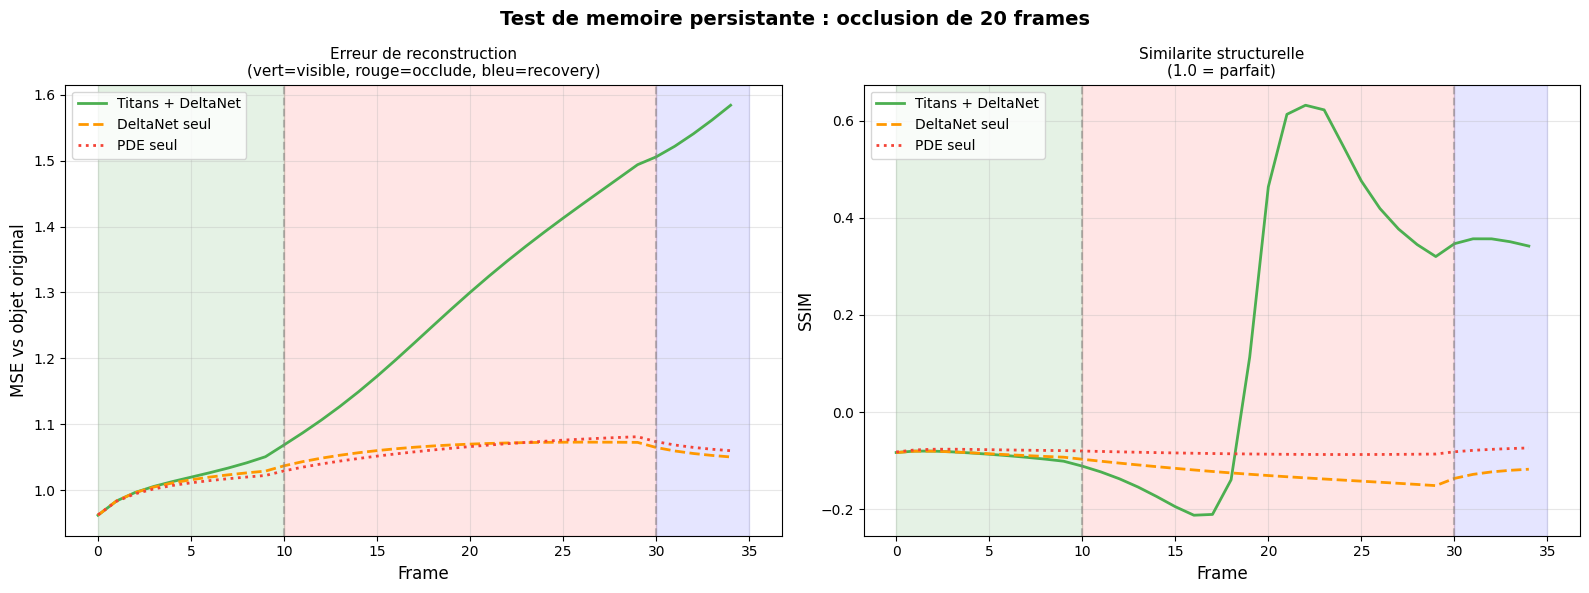

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res, color, ls in [
    ('Titans + DeltaNet', res_full, '#4CAF50', '-'),
    ('DeltaNet seul', res_no_titans, '#FF9800', '--'),
    ('PDE seul', res_pde_only, '#F44336', ':'),
]:
    axes[0].plot(res['mse'], label=name, color=color, linewidth=2, linestyle=ls)
    axes[1].plot(res['ssim'], label=name, color=color, linewidth=2, linestyle=ls)

# Marquer les phases
for ax in axes:
    ax.axvspan(0, N_SHOW_FRAMES, alpha=0.1, color='green', label='_nolegend_')
    ax.axvspan(N_SHOW_FRAMES, N_SHOW_FRAMES + 20, alpha=0.1, color='red', label='_nolegend_')
    ax.axvspan(N_SHOW_FRAMES + 20, N_SHOW_FRAMES + 20 + N_RECOVERY_FRAMES, 
               alpha=0.1, color='blue', label='_nolegend_')
    ax.axvline(N_SHOW_FRAMES, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(N_SHOW_FRAMES + 20, color='gray', linestyle='--', alpha=0.5)

axes[0].set_xlabel('Frame', fontsize=12)
axes[0].set_ylabel('MSE vs objet original', fontsize=12)
axes[0].set_title('Erreur de reconstruction\n(vert=visible, rouge=occlude, bleu=recovery)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frame', fontsize=12)
axes[1].set_ylabel('SSIM', fontsize=12)
axes[1].set_title('Similarite structurelle\n(1.0 = parfait)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Test de memoire persistante : occlusion de 20 frames', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_memory_persistence.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_memory_persistence.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Memory decay curve

Testing multiple occlusion durations to trace how memory fades over time.

In [7]:
occlusion_durations = [1, 2, 5, 10, 15, 20, 25, 30]

decay_curves = {
    'Titans + DeltaNet': {'mse': [], 'ssim': []},
    'DeltaNet seul': {'mse': [], 'ssim': []},
    'PDE seul': {'mse': [], 'ssim': []},
}

for dur in occlusion_durations:
    print(f"  Occlusion = {dur} frames...", end=" ")
    
    r1 = run_occlusion_test(True, True, dur)
    r2 = run_occlusion_test(False, True, dur)
    r3 = run_occlusion_test(False, False, dur)
    
    # MSE et SSIM a la fin de l'occlusion (juste avant recovery)
    idx_end_occlude = N_SHOW_FRAMES + dur - 1
    
    decay_curves['Titans + DeltaNet']['mse'].append(r1['mse'][idx_end_occlude])
    decay_curves['Titans + DeltaNet']['ssim'].append(r1['ssim'][idx_end_occlude])
    decay_curves['DeltaNet seul']['mse'].append(r2['mse'][idx_end_occlude])
    decay_curves['DeltaNet seul']['ssim'].append(r2['ssim'][idx_end_occlude])
    decay_curves['PDE seul']['mse'].append(r3['mse'][idx_end_occlude])
    decay_curves['PDE seul']['ssim'].append(r3['ssim'][idx_end_occlude])
    
    print("OK")

print("Balayage des durees d'occlusion termine!")

  Occlusion = 1 frames... OK
  Occlusion = 2 frames... OK
  Occlusion = 5 frames... OK
  Occlusion = 10 frames... OK
  Occlusion = 15 frames... OK
  Occlusion = 20 frames... OK
  Occlusion = 25 frames... OK
  Occlusion = 30 frames... OK
Balayage des durees d'occlusion termine!


Plot the decay curves. The gap between Titans and PDE-only should widen as occlusion gets longer. If it does not, Titans is not actually helping.

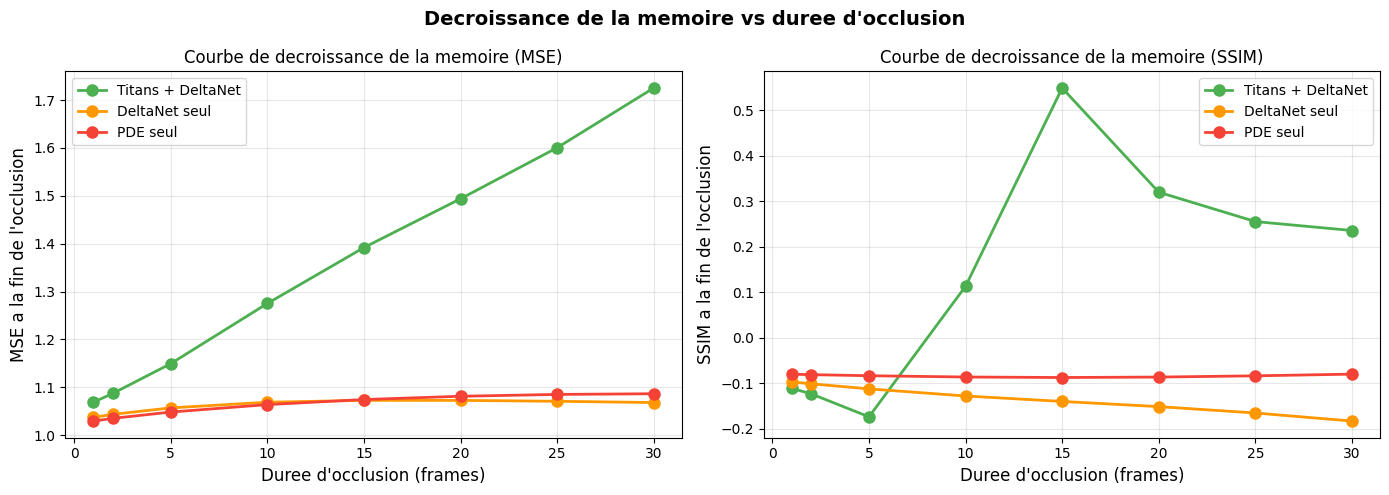

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Titans + DeltaNet': '#4CAF50', 'DeltaNet seul': '#FF9800', 'PDE seul': '#F44336'}

for name, data in decay_curves.items():
    axes[0].plot(occlusion_durations, data['mse'], marker='o', linewidth=2,
                label=name, color=colors[name], markersize=8)
    axes[1].plot(occlusion_durations, data['ssim'], marker='o', linewidth=2,
                label=name, color=colors[name], markersize=8)

axes[0].set_xlabel('Duree d\'occlusion (frames)', fontsize=12)
axes[0].set_ylabel('MSE a la fin de l\'occlusion', fontsize=12)
axes[0].set_title('Courbe de decroissance de la memoire (MSE)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Duree d\'occlusion (frames)', fontsize=12)
axes[1].set_ylabel('SSIM a la fin de l\'occlusion', fontsize=12)
axes[1].set_title('Courbe de decroissance de la memoire (SSIM)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decroissance de la memoire vs duree d\'occlusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Surprise gate activation (Titans)

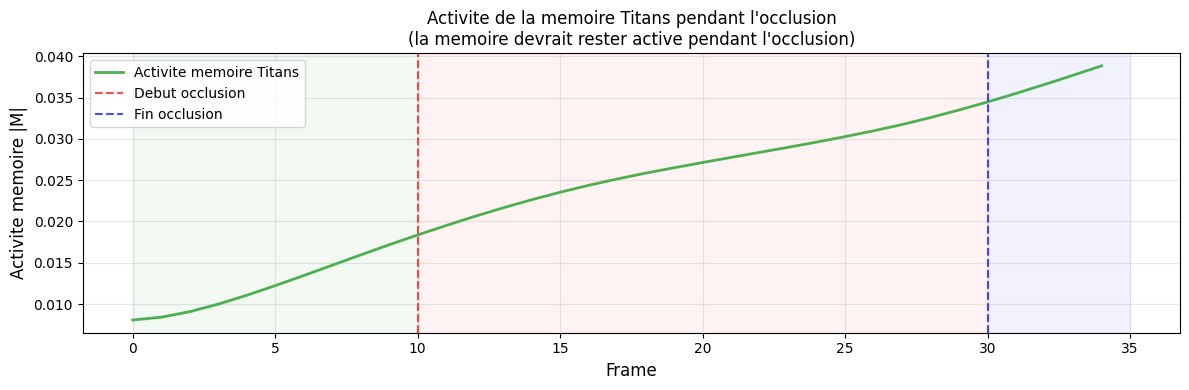

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(res_full['surprise'], color='#4CAF50', linewidth=2, label='Activite memoire Titans')

# Marquer les transitions
ax.axvline(N_SHOW_FRAMES, color='red', linestyle='--', alpha=0.7, label='Debut occlusion')
ax.axvline(N_SHOW_FRAMES + 20, color='blue', linestyle='--', alpha=0.7, label='Fin occlusion')

ax.axvspan(0, N_SHOW_FRAMES, alpha=0.05, color='green')
ax.axvspan(N_SHOW_FRAMES, N_SHOW_FRAMES + 20, alpha=0.05, color='red')
ax.axvspan(N_SHOW_FRAMES + 20, len(res_full['surprise']), alpha=0.05, color='blue')

ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Activite memoire |M|', fontsize=12)
ax.set_title('Activite de la memoire Titans pendant l\'occlusion\n(la memoire devrait rester active pendant l\'occlusion)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Field state before/during/after occlusion

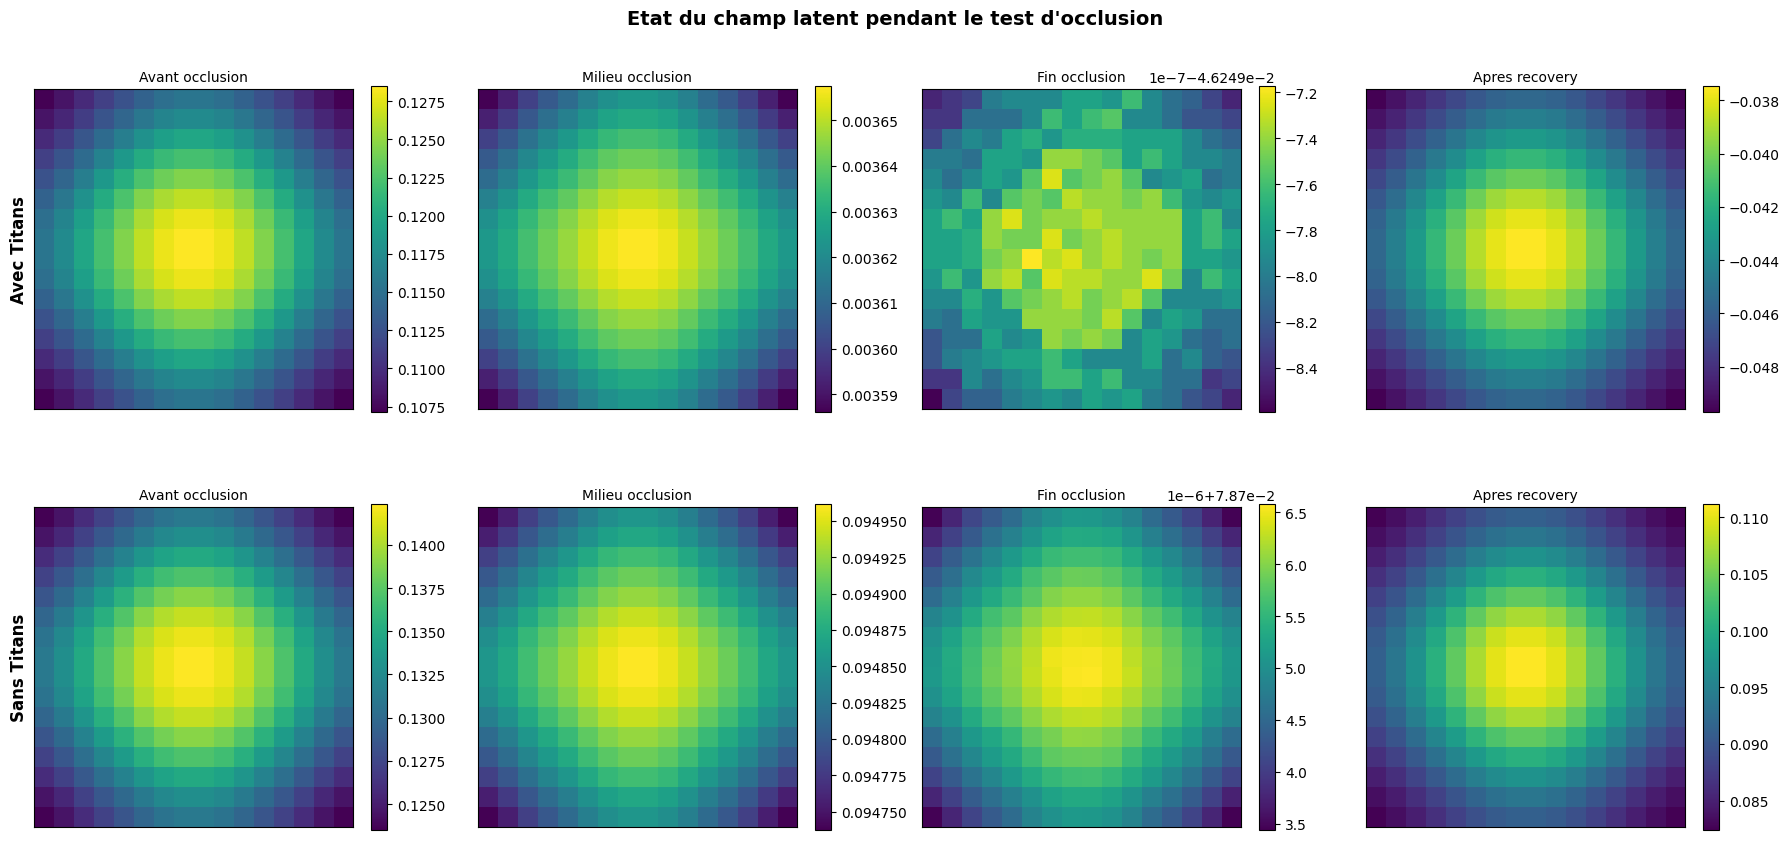

In [10]:
# Re-executer avec capture des etats intermediaires
@torch.no_grad()
def run_with_snapshots(use_titans, occlusion_duration=20):
    torch.manual_seed(42)
    bf = BeliefField(
        channels=CHANNELS, stimulus_dim=STIMULUS_DIM, spatial_hw=SPATIAL_HW,
        decay=0.95, n_evolve_steps=3, dilations=[1, 4],
        use_memory_pump=True, use_hebbian=True,
        use_deltanet=True, use_titans=use_titans,
    ).to(device)
    bf.eval()
    
    obj = create_synthetic_object(BATCH_SIZE, CHANNELS, SPATIAL_HW, device)
    stimulus = torch.zeros(BATCH_SIZE, STIMULUS_DIM, device=device)
    state = bf.init_state(BATCH_SIZE, device, torch.float32)
    
    snapshots = {}
    
    # Montrer l'objet
    for t in range(N_SHOW_FRAMES):
        state = bf.write(state, obj)
        state = bf.evolve(state, stimulus=stimulus)
    snapshots['avant_occlusion'] = state[0].cpu().clone()
    
    # Occlusion
    for t in range(occlusion_duration):
        state = bf.evolve(state, stimulus=stimulus)
        if t == occlusion_duration // 2:
            snapshots['milieu_occlusion'] = state[0].cpu().clone()
    snapshots['fin_occlusion'] = state[0].cpu().clone()
    
    # Recovery
    for t in range(N_RECOVERY_FRAMES):
        state = bf.write(state, obj)
        state = bf.evolve(state, stimulus=stimulus)
    snapshots['apres_recovery'] = state[0].cpu().clone()
    
    return snapshots

snaps_titans = run_with_snapshots(use_titans=True)
snaps_no_titans = run_with_snapshots(use_titans=False)

# Visualiser
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

titles = ['Avant occlusion', 'Milieu occlusion', 'Fin occlusion', 'Apres recovery']
keys = ['avant_occlusion', 'milieu_occlusion', 'fin_occlusion', 'apres_recovery']

for col, (key, title) in enumerate(zip(keys, titles)):
    for row, (snaps, label) in enumerate([
        (snaps_titans, 'Avec Titans'),
        (snaps_no_titans, 'Sans Titans'),
    ]):
        ax = axes[row, col]
        field = snaps[key].mean(dim=0).numpy()  # Moyenne des canaux
        im = ax.imshow(field, cmap='viridis', aspect='equal')
        plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_title(f'{title}', fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=12, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Etat du champ latent pendant le test d\'occlusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation

### How TitansMemory works

TitansMemory is a fast-weight associative memory. On write, features of an observed object get stored in the memory bank M via soft addressing. On read, the BeliefField queries memory to retrieve relevant information. The surprise gate measures the gap between prediction (memory) and observation: high surprise triggers a stronger update.

### Object permanence

Key concept from developmental psychology (Piaget, stage 3-4): a baby understands objects continue to exist even when not visible. For a world model, the system has to maintain a representation of the occluded object.

### What I expected to see

- **With Titans**: MSE after occlusion stays moderate. Memory preserved the information.
- **Without Titans**: MSE climbs fast. The PDE diffuses information without preserving it.
- The decay curve should be much slower with Titans.

### Architectural takeaway

Titans gives FluidWorld a clean separation between the PDE ("how the world changes", local dynamics, diffusion) and Titans memory ("what the world is", persistent object templates).